In [69]:
import pandas as pd
import plotly.express as px
from pathlib import Path

from UNregionChoroplethGenerator import create_un_region_choropleth

cwd = Path.cwd()

# Input paths
results_folder =  cwd.parent / "results"
file_path_ECWByCountry = results_folder / "ECWByCountry.csv"
file_path_ECWByRegion = results_folder / "ECWByRegion.csv"

# Output paths
ECWbyRegionLowerBound_PATH = results_folder / "ECWbyRegionLowerBound.html"
ECWbyRegionUpperBound_PATH = results_folder / "ECWbyRegionUpperBound.html"
ECWbyCountryLowerBound_PATH = results_folder / "ECWbyCountryLowerBound.html"
ECWbyCountryUpperBound_PATH = results_folder / "ECWbyCountryUpperBound.html"


### Create Region plots

In [70]:
df_region = pd.read_csv(file_path_ECWByRegion)
ECWbyRegionLowerBound = create_un_region_choropleth(df_region, region_col="Region", value_col="%ECW Poll", title="%ECW by Region Lower Bound", color_scale="Greens")
ECWbyRegionUpperBound = create_un_region_choropleth(df_region, region_col="Region", value_col="%ECW ILO", title="%ECW by Region Upper Bound", color_scale="Greens")
# fig1.show()
# fig2.show()

### Create Country plots

In [71]:
# Load your data
df_country = pd.read_csv(file_path_ECWByCountry)

# First map: ECW ILO
ECWbyCountryUpperBound = px.choropleth(
    df,
    locations="Country Code",
    locationmode="ISO-3",
    color="%ECW ILO",
    hover_name="Country Code",
    color_continuous_scale='spectral',
    title="Upper bound of Exposed Vital Workers by Country"
)

# Second map: ECW Poll
ECWbyCountryLowerBound = px.choropleth(
    df,
    locations="Country Code",
    locationmode="ISO-3",
    color="%ECW Poll",
    hover_name="Country Code",
    color_continuous_scale='spectral',
    title="Lower bound of Exposed Critical Workers by Country"
)

### Save plots

In [72]:
ECWbyRegionLowerBound_PATH = results_folder / "ECWbyRegionLowerBound.html"
ECWbyRegionUpperBound_PATH = results_folder / "ECWbyRegionUpperBound.html"
ECWbyCountryLowerBound_PATH = results_folder / "ECWbyCountryLowerBound.html"
ECWbyCountryUpperBound_PATH = results_folder / "ECWbyCountryUpperBound.html"


ECWbyRegionLowerBound.write_html(ECWbyRegionLowerBound_PATH)
ECWbyRegionUpperBound.write_html(ECWbyRegionUpperBound_PATH)
ECWbyCountryLowerBound.write_html(ECWbyCountryLowerBound_PATH)
ECWbyCountryUpperBound.write_html(ECWbyCountryUpperBound_PATH)

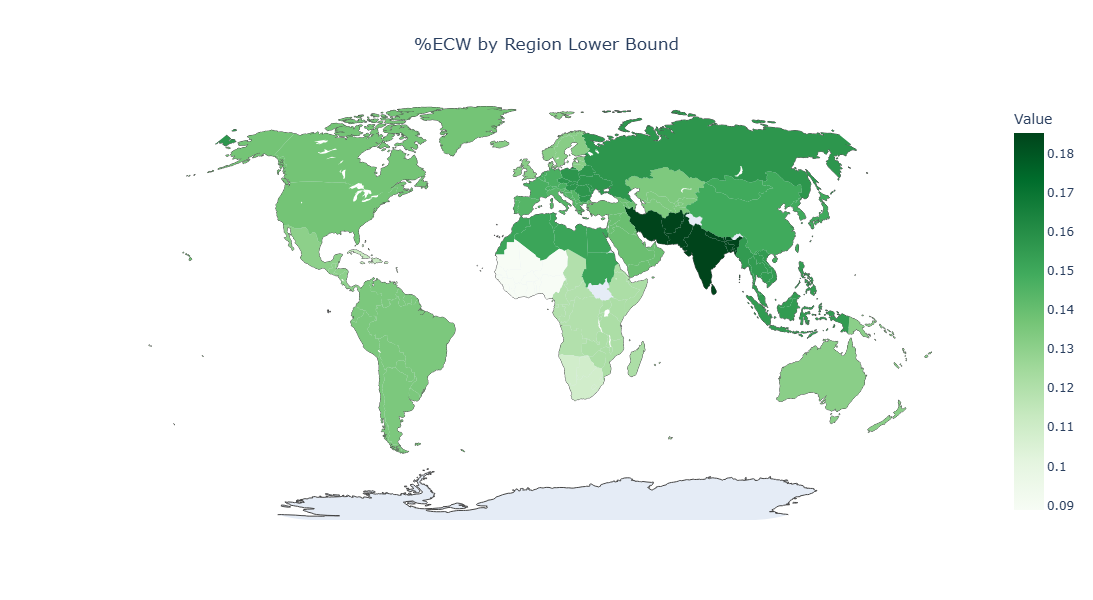

In [73]:
ECWbyRegionLowerBound.update_layout(
    geo=dict(
        showcountries=False,
        showcoastlines=True,
        showframe=False,
        projection_type='natural earth'
    )
)
ECWbyRegionLowerBound.update_traces(
    marker_line_width=0  # This removes the borders around the colored regions
)